# <b>Sales Forecasting Project - EDA After Feature Engineering </b>

##  Objectives 

This project aims to develop a **Sales Forecasting System** powered by data analysis and machine learning techniques, in order to achieve the following objectives:

* **Analyze historical data** related to sales, customers, and discounts to uncover hidden patterns and relationships.
* **Support managerial decision-making** by providing insights that help anticipate demand, manage inventory, and optimize pricing strategies.
* **Address influencing factors** such as discounts, seasonality, and different sales periods (monthly, quarterly, yearly).
* **Build a Real-Time Forecasting Model** that can accurately predict future sales.
* **Improve operational efficiency** and reduce risks associated with inaccurate sales estimations.


# Import Libraries
----------- ------------
##### Add any other libraries you need (XGBoost, Prophet, LightGBM, etc.)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
----------- ------------

In [ ]:
# 1. Load the dataset
file_path = "car_sales_2018_2024_cleaned.csv"
df = pd.read_csv(file_path)

# Feature Engineering
----------- ------------
#### - Extract features from date (Year, Month, Day, Weekday, etc.)
#### - Encode categorical variables
#### - Scaling if needed


### Calculating Car Age
This feature is crucial for identifying which older or newer cars are in higher demand and understanding their impact on sales.

In [ ]:
# Car Age
df["Car Age"] = df["Sale Year"] - df["Car Year"]
df["Car Age"].describe()

count    803990.000000
mean          0.973304
std           2.597559
min          -6.000000
25%          -1.000000
50%           1.000000
75%           3.000000
max           6.000000
Name: Car Age, dtype: float64

 <b>Potential Insights:</b>

- Newer cars generally have higher demand.

- We can identify which models require higher stock levels based on their age.

In [ ]:
invalid_car_age = df[df["Sale Year"] < df["Car Year"]]
print(invalid_car_age.shape)

(227718, 27)


In [ ]:
df.loc[df["Sale Year"] < df["Car Year"], "Sale Year"] = df["Car Year"]

In [ ]:
df["Car Age"] = df["Sale Year"] - df["Car Year"]
df["Car Age"].describe()

count    803990.000000
mean          1.607151
std           1.788197
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max           6.000000
Name: Car Age, dtype: float64

### Calculating Profit Margin per Sale
This feature is key for identifying the most profitable sales and where the dealership should focus its promotions.

In [ ]:
# Profit Margin
df["Profit Margin"] = df["Profit"] / df["Sale Price"]
df["Profit Margin"].describe()

count    803990.000000
mean          0.204158
std           0.109014
min          -0.207201
25%           0.147470
50%           0.226861
75%           0.287402
max           1.621199
Name: Profit Margin, dtype: float64

In [ ]:
df[df["Profit Margin"] < 0]
df[df["Profit Margin"] > 1]

,Date,Salesperson,Customer Name,Customer Age,Customer Gender,Car Make,Car Model,Car Year,Quantity,Sale Price,...,Sale Month,Sale Quarter,Day of Week,Season,Sale Month Num,Loss,Profit_Clean,Discount_Bracket,Car Age,Profit Margin
46496,2021-03-14,Benjamin Beck,Samantha Fitzgerald,23.0,Male,Honda,Civic,2023,1.0,14829.0,...,March,1,Sunday,Spring,3,0.0,15670.51,0-5%,0,1.056748
55676,2023-08-18,Rebecca Smith,Tiffany Payne,59.0,Female,Kia,Optima,2024,2.0,15513.0,...,August,3,Friday,Summer,8,0.0,15670.51,5-10%,0,1.010153
89201,2021-07-28,Lynn Jenkins,Amanda Chavez,36.0,Male,Kia,Sorento,2024,1.0,9666.0,...,July,3,Wednesday,Summer,7,0.0,15670.51,0-5%,0,1.621199
110768,2021-04-07,Jill Jones,Amber Grant,52.0,Male,Kia,Optima,2021,1.0,14414.0,...,April,2,Wednesday,Spring,4,0.0,15670.51,0-5%,0,1.087173
136127,2023-06-02,Mary Simon,Kimberly Key,59.0,Female,Hyundai,Kona,2021,1.0,15465.0,...,June,2,Friday,Summer,6,0.0,15670.51,5-10%,0,1.013289
289810,2018-02-28,Richard Rogers,Vincent Brown,68.0,Female,Toyota,Prius,2019,1.0,13188.0,...,February,1,Wednesday,Winter,2,0.0,15670.51,0-5%,0,1.188240
487544,2018-04-15,Ralph Dunn,Pam Gordon,43.0,Male,Hyundai,Tucson,2023,1.0,14294.0,...,April,2,Sunday,Spring,4,0.0,15670.51,0-5%,0,1.096300
494463,2024-11-03,Timothy Wheeler,Christine Baker,60.0,Female,Hyundai,Santa Fe,2020,2.0,15593.0,...,November,4,Sunday,Fall,11,0.0,15670.51,5-10%,0,1.004971
497639,2022-01-10,Ralph Dunn,Ryan Williams,68.0,Female,Nissan,Maxima,2020,1.0,15633.0,...,January,1,Monday,Winter,1,0.0,15670.51,5-10%,0,1.002399
523967,2018-07-11,Chris Johnson,Alyssa Wilson,70.0,Male,Hyundai,Santa Fe,2022,1.0,15592.0,...,July,3,Wednesday,Summer,7,0.0,15670.51,0-5%,0,1.005035


In [89]:
df = df[(df["Profit Margin"] <= 1) & (df["Profit Margin"] >= 0)]

In [ ]:
df[df["Profit Margin"] < 0]
df[df["Profit Margin"] > 1]

,Date,Salesperson,Customer Name,Customer Age,Customer Gender,Car Make,Car Model,Car Year,Quantity,Sale Price,...,Sale Month,Sale Quarter,Day of Week,Season,Sale Month Num,Loss,Profit_Clean,Discount_Bracket,Car Age,Profit Margin


In [ ]:
df["Profit Margin"] = df["Profit"] / df["Sale Price"]
df["Profit Margin"].describe()

C:\Users\kira\AppData\Local\Temp\ipykernel_14428\4270428701.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit Margin'] = df['Profit'] / df['Sale Price']


count    7.570270e+05
mean     2.206029e-01
std      8.858288e-02
min      5.042864e-07
25%      1.636234e-01
50%      2.338864e-01
75%      2.915229e-01
max      9.993948e-01
Name: Profit Margin, dtype: float64

<b>Potential Insights:</b>

- Models or car categories with high profit margins → invest more in marketing them.

- Cars with weak margins → may require re-evaluating pricing or discount strategies.

### Encoding Seasonal and Time-Based Features
This helps in analyzing seasonality and sales trends throughout the year and week.

In [ ]:
# Is Weekend
df["Is Weekend"] = df["Day of Week"].isin(["Saturday", "Sunday"]).astype(int)

# Season One-Hot Encoding
season_dummies = pd.get_dummies(df["Season"], prefix="Season")
df = pd.concat([df, season_dummies], axis=1)

C:\Users\kira\AppData\Local\Temp\ipykernel_14428\4190725248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Is Weekend'] = df['Day of Week'].isin(['Saturday', 'Sunday']).astype(int)


<b>Potential Insights:</b>
- Analyze sales per season → identify peak periods.

- Plan inventory based on seasonal demand.

### Customer Age Group Categorization
Important for analyzing which age group buys which car type the most.

In [ ]:
bins = [20, 30, 40, 50, 60, 71]
labels = ["20-30", "31-40", "41-50", "51-60", "61-70"]
df["Customer Age Group"] = pd.cut(
    df["Customer Age"], bins=bins, labels=labels, right=False
)  # right=False includes left edge

<b>Potential Insights:</b>

- Identify the highest purchasing age groups → target marketing campaigns.

- Select car models that appeal to specific age demographics.

### Discount relative to Car Age
This shows the impact of discounts on profit, especially for older inventory.

In [ ]:
df["Discount per Car Age"] = df["Discount"] / (
    df["Car Age"] + 1
)  # +1 to avoid division by zero

In [ ]:
df[["Discount per Car Age", "Car Age"]].describe()

,Discount per Car Age,Car Age
count,757027.000000,757027.000000
mean,0.035522,1.627894
std,0.031981,1.795043
min,0.000000,0.000000
25%,0.010000,0.000000
50%,0.025000,1.000000
75%,0.050000,3.000000
max,0.150000,6.000000


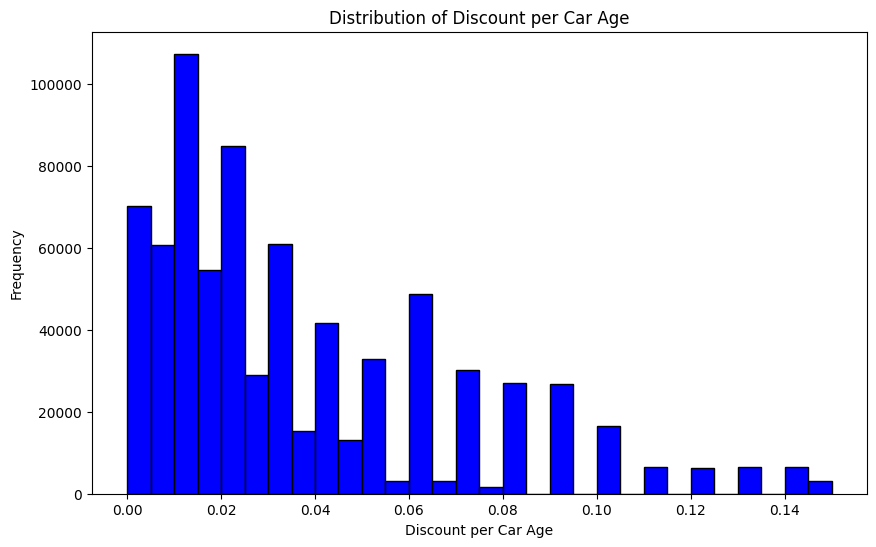

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df["Discount per Car Age"], bins=30, color="blue", edgecolor="black")
plt.title("Distribution of Discount per Car Age")
plt.xlabel("Discount per Car Age")
plt.ylabel("Frequency")
plt.show()

<b>Potential Insights:</b>

- Understand if discounting older cars effectively increases sales.

- Adjust discounting strategies for aging stock.

In [98]:
# Check
print("Final Shape:", df.shape)
df.info()
df.describe(include="all")

Final Shape: (757027, 35)
<class 'pandas.core.frame.DataFrame'>
Index: 757027 entries, 0 to 803989
Data columns (total 35 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Date                  757027 non-null  datetime64[ns]
 1   Salesperson           757027 non-null  object        
 2   Customer Name         757027 non-null  object        
 3   Customer Age          757027 non-null  float64       
 4   Customer Gender       757027 non-null  object        
 5   Car Make              757027 non-null  object        
 6   Car Model             757027 non-null  object        
 7   Car Year              757027 non-null  int64         
 8   Quantity              757027 non-null  float64       
 9   Sale Price            757027 non-null  float64       
 10  Cost                  757027 non-null  float64       
 11  Profit                757027 non-null  float64       
 12  Discount              757027 non-null

,Date,Salesperson,Customer Name,Customer Age,Customer Gender,Car Make,Car Model,Car Year,Quantity,Sale Price,...,Discount_Bracket,Car Age,Profit Margin,Is Weekend,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Customer Age Group,Discount per Car Age
count,757027,757027,757027,757027.000000,757027,757027,757027,757027.00000,757027.000000,757027.000000,...,757027,757027.000000,7.570270e+05,757027.000000,757027,757027,757027,757027,757027,757027.000000
unique,NaN,49,282644,NaN,2,10,50,NaN,NaN,NaN,...,3,NaN,NaN,NaN,2,2,2,2,5,NaN
top,NaN,Eileen Callahan,Michael Johnson,NaN,Male,Toyota,S-Class,NaN,NaN,NaN,...,0-5%,NaN,NaN,NaN,False,False,False,False,41-50,NaN
freq,NaN,15669,309,NaN,402361,119633,57069,NaN,NaN,NaN,...,338565,NaN,NaN,NaN,580177,530852,578688,581364,187040,NaN
mean,2021-05-23 10:09:20.505239296,NaN,NaN,45.023985,NaN,NaN,NaN,2020.99799,2.077745,78097.362348,...,NaN,1.627894,2.206029e-01,0.268696,NaN,NaN,NaN,NaN,NaN,0.035522
min,2018-01-01 00:00:00,NaN,NaN,20.000000,NaN,NaN,NaN,2018.00000,1.000000,9508.000000,...,NaN,0.000000,5.042864e-07,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,2019-06-22 00:00:00,NaN,NaN,33.000000,NaN,NaN,NaN,2019.00000,2.000000,55563.400000,...,NaN,0.000000,1.636234e-01,0.000000,NaN,NaN,NaN,NaN,NaN,0.010000
50%,2021-04-27 00:00:00,NaN,NaN,45.000000,NaN,NaN,NaN,2021.00000,2.000000,73899.040000,...,NaN,1.000000,2.338864e-01,0.000000,NaN,NaN,NaN,NaN,NaN,0.025000
75%,2023-02-27 00:00:00,NaN,NaN,57.000000,NaN,NaN,NaN,2023.00000,2.000000,98468.370000,...,NaN,3.000000,2.915229e-01,1.000000,NaN,NaN,NaN,NaN,NaN,0.050000
max,2024-12-31 00:00:00,NaN,NaN,70.000000,NaN,NaN,NaN,2024.00000,3.000000,166229.600000,...,NaN,6.000000,9.993948e-01,1.000000,NaN,NaN,NaN,NaN,NaN,0.150000


### Save the dataset


In [99]:
df.to_csv("car_sales_2018_2024_Cleaned&Engineered_Features.csv", index=False)
print(" Cleaned dataset saved")

 Cleaned dataset saved


### Preparing the data for machine learning models

#### Next year Sales prediction "Prophet"

In [133]:
df = pd.read_csv("car_sales_2018_2024_Cleaned&Engineered_Features.csv")

In [ ]:
df["Total_Sales"] = df["Sale Price"] * df["Quantity"]

In [ ]:
# 1. Aggregate monthly sales and keep useful columns from original df
monthly_sales = (
    df.groupby(["Sale Year", "Sale Month Num"], observed=False)
    .agg({"Sale Price": "sum"})
    .reset_index()
)

In [ ]:
# 2. Create a proper date column for time-series
monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Sale Year"].astype(str)
    + "-"
    + monthly_sales["Sale Month Num"].astype(str)
    + "-01"
)

In [ ]:
# 3. Sort by date
monthly_sales = monthly_sales.sort_values("Date")

In [ ]:
# 4. Rename column for clarity
monthly_sales.rename(columns={"Sale Price": "Total_Sales"}, inplace=True)

In [ ]:
# 5. Create lag features (previous months sales)
monthly_sales["Sales_t-1"] = monthly_sales["Total_Sales"].shift(1)
monthly_sales["Sales_t-2"] = monthly_sales["Total_Sales"].shift(2)
monthly_sales["Sales_t-3"] = monthly_sales["Total_Sales"].shift(3)

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"


monthly_sales["Season"] = monthly_sales["Sale Month Num"].apply(get_season)

In [ ]:
# 6. Create rolling mean features (moving averages)
monthly_sales["Rolling_3M"] = monthly_sales["Total_Sales"].rolling(window=3).mean()
monthly_sales["Rolling_6M"] = monthly_sales["Total_Sales"].rolling(window=6).mean()

In [ ]:
# 7. Create the target: next month sales
monthly_sales["Next_Month_Sales"] = monthly_sales["Total_Sales"].shift(-1)

In [24]:
# 8. Drop rows with NaN values (first few rows because of lags/rolling)
monthly_sales = monthly_sales.dropna().reset_index(drop=True)

In [ ]:
# Cumulative Sales per year
monthly_sales["Cumulative_Sales"] = monthly_sales.groupby("Sale Year")[
    "Total_Sales"
].cumsum()

In [ ]:
monthly_sales["Sale Quarter"] = (
    (monthly_sales["Sale Month Num"].astype("int") - 1) // 3
) + 1

In [40]:
monthly_sales.head()

,Sale Year,Sale Month Num,Total_Sales,Date,Sales_t-1,Sales_t-2,Sales_t-3,Rolling_3M,Rolling_6M,Next_Month_Sales,Season,Cumulative_Sales,Sale Quarter
0,2018,6,19049860.55,2018-06-01,19428931.62,19905920.23,20462240.27,1.946157e+07,2.216595e+07,17946407.51,Summer,19049860.55,2
1,2018,7,17946407.51,2018-07-01,19049860.55,19428931.62,19905920.23,1.880840e+07,1.916096e+07,18825481.33,Summer,36996268.06,3
2,2018,8,18825481.33,2018-08-01,17946407.51,19049860.55,19428931.62,1.860725e+07,1.926981e+07,18642575.78,Summer,55821749.39,3
3,2018,9,18642575.78,2018-09-01,18825481.33,17946407.51,19049860.55,1.847149e+07,1.896653e+07,20383361.54,Fall,74464325.17,3
4,2018,10,20383361.54,2018-10-01,18642575.78,18825481.33,17946407.51,1.928381e+07,1.904610e+07,18226782.23,Fall,94847686.71,4


In [46]:
monthly_sales.to_csv("car_sales_2018_2024_prophet_df.csv", index=False)
print(" prophet dataset saved")

 prophet dataset saved


#### Next Year Sales prediction "ML"

In [3]:
df = pd.read_csv("car_sales_2018_2024_Cleaned&Engineered_Features.csv")

In [4]:
# Target
df["Total_Sales"] = df["Quantity"] * df["Sale Price"]

In [ ]:
features = [
    "Sale Year",
    "Sale Month Num",
    "Sale Quarter",
    "Day of Week",
    "Is Weekend",
    "Season_Fall",
    "Season_Spring",
    "Season_Summer",
    "Season_Winter",
    "Car Make",
    "Car Model",
    "Car Year",
    "Car Age",
    "Discount",
    "Discount per Car Age",
    "Profit Margin",
]

target = "Total_Sales"

In [6]:
ml_df = df[features + [target]].copy()

In [7]:
ml_df.head()

,Sale Year,Sale Month Num,Sale Quarter,Day of Week,Is Weekend,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Car Make,Car Model,Car Year,Car Age,Discount,Discount per Car Age,Profit Margin,Total_Sales
0,2020,9,3,Monday,0,True,False,False,False,Audi,Q7,2018,2,0.01,0.003333,0.075435,243129.12
1,2023,4,2,Sunday,1,False,True,False,False,Toyota,Corolla,2019,4,0.11,0.022000,0.300000,138221.36
2,2024,12,4,Thursday,0,False,False,False,True,Ford,Explorer,2019,5,0.07,0.011667,0.260435,179987.44
3,2021,12,4,Thursday,0,False,False,False,True,Toyota,Telluride,2021,0,0.09,0.090000,0.143217,99843.04
4,2020,9,3,Thursday,0,True,False,False,False,Kia,Sorento,2020,0,0.09,0.090000,0.178187,24205.00


In [ ]:
# One-Hot Encoding for Day of Week
day_encoded = pd.get_dummies(df["Day of Week"], prefix="Day")

In [ ]:
# One-Hot Encoding for Car Make
car_make_encoded = pd.get_dummies(df["Car Make"], prefix="Make")

In [ ]:
# Frequency Encoding for Car Model
car_model_encoded = (
    df["Car Model"].map(df["Car Model"].value_counts(normalize=True)).to_frame()
)
car_model_encoded.columns = ["Car_Model_Freq"]

In [ ]:
# We collect the data together
df_encoded = pd.concat(
    [
        df.drop(["Day of Week", "Car Make", "Car Model"], axis=1),
        day_encoded,
        car_make_encoded,
        car_model_encoded,
    ],
    axis=1,
)

In [12]:
print("Data after encoding is ready for ML")
print(df_encoded.head())

Data after encoding is ready for ML
         Date     Salesperson    Customer Name  Customer Age Customer Gender  \
0  2022-09-28   Victor Flores  Joshua Williams          37.0          Female   
1  2019-04-27    Amy Peterson    Raymond Bates          44.0          Female   
2  2021-12-09    Sharon Smith  Rebecca Stevens          32.0            Male   
3  2023-12-28  Robin Cantrell     Michael Rice          69.0            Male   
4  2023-09-14   Matthew Gross     Ricky Gordon          55.0          Female   

   Car Year  Quantity  Sale Price       Cost    Profit  ...  Make_Bmw  \
0      2018       2.0   121564.56  112394.29   9170.27  ...     False   
1      2019       2.0    69110.68   48377.48  20733.20  ...     False   
2      2019       2.0    89993.72   66556.19  23437.53  ...     False   
3      2021       2.0    49921.52   42771.92   7149.60  ...     False   
4      2020       1.0    24205.00   19891.98   4313.02  ...     False   

  Make_Chevrolet  Make_Ford  Make_Honda Make

In [40]:
df_encoded.to_csv("car_sales_Next_Year_Sales_prediction_ML_df.csv", index=False)
print("ML dataset saved")

NameError: name 'df_encoded' is not defined

#### Extract a sample representing the population

In [ ]:
# We take 100,000 random rows to represent the data.
df = pd.read_csv("car_sales_Next_Year_Sales_prediction_ML_df.csv")
df_sample = df.sample(n=100000, random_state=4)

In [ ]:
# calculate sample statistics
def calculate_sample_stats(df_sample, num_cols):
    stats_dict = {}
    for col in num_cols:
        sample = df_sample[col]
        stats_dict[col] = {"mean": sample.mean(), "std": sample.std(), "n": len(sample)}
    return stats_dict

In [ ]:
# 2. Calculate population means
population_means = df.select_dtypes(include=["int64", "float64"]).mean().to_dict()

# 3. Calculate sample statistics
num_cols = df_sample.select_dtypes(include=[np.number]).columns
sample_stats = calculate_sample_stats(df_sample, num_cols)

 **Hypothesis Testing: Two-Tailed One-Sample Z-Test** 

In [ ]:
z_test_results = []

for col in num_cols:
    # Get the pre-calculated statistics
    sample_mean = sample_stats[col]["mean"]
    sample_std = sample_stats[col]["std"]
    n = sample_stats[col]["n"]
    pop_mean = population_means.get(col, None)

    # Calculate Z-score and p-value
    if sample_std != 0:
        z_score = (sample_mean - pop_mean) / (sample_std / np.sqrt(n))
        p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # two-tailed
        test_used = "Z-Test"

        z_test_results.append(
            {
                "Column": col,
                "Population Mean": round(pop_mean, 3),
                "Sample Mean": round(sample_mean, 3),
                "Test": test_used,
                "Z/T Score": round(z_score, 3),
                "p-value": round(p_value, 4),
                "Representative?": "Yes" if p_value > 0.05 else "No",
            }
        )

z_df = pd.DataFrame(z_test_results)
print("Z-Test Results:")
print(z_df)

Z-Test Results:
                  Column  Population Mean  Sample Mean    Test  Z/T Score  \
0           Customer Age           45.024       44.969  Z-Test     -1.230   
1               Car Year         2020.998     2020.999  Z-Test      0.234   
2               Quantity            2.078        2.078  Z-Test      0.143   
3             Sale Price        78097.362    78080.508  Z-Test     -0.167   
4                   Cost        60405.470    60393.915  Z-Test     -0.157   
5                 Profit        17838.310    17837.858  Z-Test     -0.013   
6               Discount            0.060        0.060  Z-Test      0.920   
7        Commission Rate            0.071        0.071  Z-Test      0.757   
8      Commission Earned         5536.453     5534.857  Z-Test     -0.185   
9              Sale Year         2022.626     2022.626  Z-Test     -0.034   
10          Sale Quarter            2.535        2.537  Z-Test      0.512   
11        Sale Month Num            6.153        6.162  Z-Te

**Confidence Interval Calculation**

In [ ]:
ci_results = []

for col in num_cols:
    # Get the pre-calculated statistics
    sample_mean = sample_stats[col]["mean"]
    sample_std = sample_stats[col]["std"]
    n = sample_stats[col]["n"]
    pop_mean = population_means.get(col, None)

    # Calculate Confidence Interval
    confidence = 0.95
    se = sample_std / np.sqrt(n)
    z_val = stats.norm.ppf(1 - (1 - confidence) / 2)
    lower = sample_mean - z_val * se
    upper = sample_mean + z_val * se
    inside = lower <= pop_mean <= upper if pop_mean is not None else None

    ci_results.append(
        {
            "Column": col,
            "Sample Mean": round(sample_mean, 3),
            f"{int(confidence*100)}% CI Lower": round(lower, 3),
            f"{int(confidence*100)}% CI Upper": round(upper, 3),
            "Population Mean": round(pop_mean, 3),
            "Inside Interval?": inside,
        }
    )

ci_df = pd.DataFrame(ci_results)
print("\nConfidence Interval Results:")
print(ci_df)


Confidence Interval Results:
                  Column  Sample Mean  95% CI Lower  95% CI Upper  \
0           Customer Age       44.969        44.880        45.057   
1               Car Year     2020.999      2020.987      2021.011   
2               Quantity        2.078         2.074         2.082   
3             Sale Price    78080.508     77882.294     78278.723   
4                   Cost    60393.915     60249.315     60538.516   
5                 Profit    17837.858     17770.209     17905.507   
6               Discount        0.060         0.060         0.060   
7        Commission Rate        0.071         0.071         0.071   
8      Commission Earned     5534.857      5517.990      5551.723   
9              Sale Year     2022.626      2022.617      2022.634   
10          Sale Quarter        2.537         2.530         2.544   
11        Sale Month Num        6.162         6.139         6.184   
12                  Loss        0.000         0.000         0.000   
13  

# EDA After Feature Engineering 
----------- ------------

In [100]:
df = pd.read_csv("car_sales_2018_2024_Cleaned&Engineered_Features.csv")

### Customer Segmentation by Age & Purchase Behavior
- Identify which age group generates the highest average profit per transaction.
- Actionable Improvement: Design targeted promotions for the most profitable demographics.

In [ ]:
customer_segment = df.groupby("Customer Age Group").agg(
    {"Quantity": "mean", "Profit": "mean"}
)
print(customer_segment)

                    Quantity        Profit
Customer Age Group                        
20-30               2.074929  17836.385671
31-40               2.077448  17829.797408
41-50               2.078534  17859.814418
51-60               2.078881  17844.056871
61-70               2.078569  17816.314968


### Car Age vs Profitability Analysis
- Determine the optimal car age that yields the highest average profit.
- Actionable Improvement: Adjust pricing or discount strategies based on vehicle age.

In [ ]:
# Group by Car_Age and calculate average profit
car_age_profit = df.groupby("Car Age")["Profit"].mean()
print(
    car_age_profit.sort_values(ascending=False).head(10)
)  # Show top 10 most profitable ages

Car Age
5    22224.114478
4    21692.924506
6    20627.938749
3    19786.651698
2    19476.253256
1    18464.643674
0    14887.377628
Name: Profit, dtype: float64


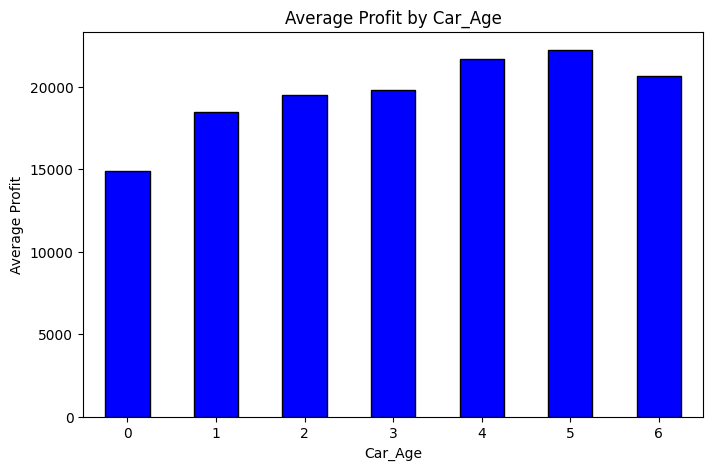

In [ ]:
car_age_profit.plot(kind="bar", figsize=(8, 5), color="blue", edgecolor="k")

plt.title("Average Profit by Car_Age")
plt.xlabel("Car_Age")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.show()

<b>Insight:</b> 

Used cars (especially 4–6 years old) generate higher profit margins than brand-new cars. This suggests the dealership could increase focus on sourcing and promoting slightly older used cars, as they offer better profitability compared to new cars.

### Weekend vs Weekday Performance
- Compare total sales volume and profit on weekends vs. weekdays.
- Actionable Improvement: Plan special weekend promotions or events to boost sales further.

In [ ]:
weekend_perf = df.groupby("Is Weekend").agg({"Quantity": "sum", "Profit": "sum"})
weekend_perf.index = weekend_perf.index.map({0: "No", 1: "Yes"})
print(weekend_perf)

             Quantity        Profit
Is Weekend                         
No          1150272.0  9.868841e+09
Yes          422637.0  3.635241e+09


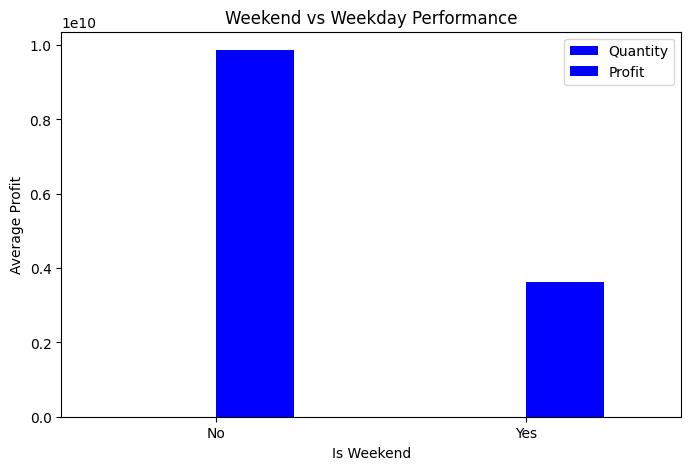

In [ ]:
weekend_perf.plot(kind="bar", figsize=(8, 5), color="blue")

plt.title("Weekend vs Weekday Performance")
plt.xlabel("Is Weekend")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.show()

<b>Insight:</b> 

Sales and profits are significantly higher during weekdays compared to weekends. This suggests that the dealership should focus on increasing weekend promotions or special offers to boost sales during low-traffic periods.

### Customer Age Group & Car Model Preference

- Discover the preferred car models for different customer age groups.
  
- Actionable Improvement: Tailor showroom displays, online ads, and sales pitches to match the preferences of the target age demographic.

In [ ]:
age_model_preference = pd.pivot_table(
    df,
    values="Quantity",
    index="Customer Age Group",
    columns="Car Model",
    aggfunc="sum",
    fill_value=0,
)
# Print a summary, perhaps the top 3 models for each age group
print(age_model_preference.apply(lambda x: x.nlargest(3).index.tolist(), axis=1))

Customer Age Group
20-30    [S-Class, Forte, Elantra]
31-40     [S-Class, Forte, Tucson]
41-50    [S-Class, Equinox, Focus]
51-60       [S-Class, Kona, Pilot]
61-70      [S-Class, Camry, Civic]
dtype: object


<b>Insight:</b>

Across all age groups, the Mercedes S-Class consistently appears as a preferred model, indicating its strong brand appeal and desirability across generations. Meanwhile, younger customers (20–40) tend to prefer compact and affordable models like Forte, Elantra, and Tucson, while older groups (50–70) lean toward family-oriented or practical models such as Pilot, Camry, and Civic.
